Dataset shape: (569, 31)

Target classes: ['malignant' 'benign']

First 5 rows:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fra

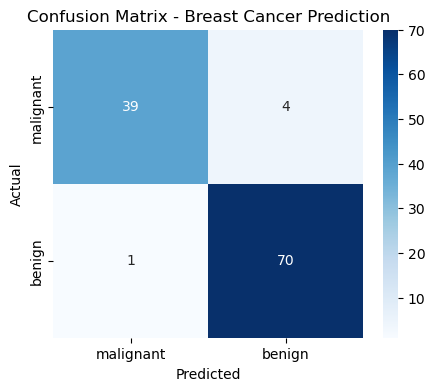


Example Prediction:
Predicted Class: benign
Probability of being malignant: 0.88


In [1]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Step 1: Load Dataset
# ---------------------------
data = load_breast_cancer()
X = data.data
y = data.target

# Convert to DataFrame for better readability
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

print("Dataset shape:", df.shape)
print("\nTarget classes:", data.target_names)
print("\nFirst 5 rows:\n", df.head())

# ---------------------------
# Step 2: Split Data
# ---------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------
# Step 3: Train Logistic Regression Model
# ---------------------------
model = LogisticRegression(max_iter=5000)  # increased iterations for convergence
model.fit(X_train, y_train)

# ---------------------------
# Step 4: Make Predictions
# ---------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

# ---------------------------
# Step 5: Evaluate the Model
# ---------------------------
print("\n✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=data.target_names))

# ---------------------------
# Step 6: Visualization
# ---------------------------
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Breast Cancer Prediction')
plt.show()

# ---------------------------
# Step 7: Example Prediction
# ---------------------------
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0][1]

print("\nExample Prediction:")
print(f"Predicted Class: {data.target_names[prediction]}")
print(f"Probability of being malignant: {probability:.2f}")
